<a href="https://colab.research.google.com/github/Fofita911/Fisica-computacional/blob/main/PROYECTO_4_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


 CASO: hx=0.1, ht=0.0005

 i   x_i     exacta     explícito      implícito
--------------------------------------------------------
 0  0.00   0.000000   0.000000   0.000000
 1  0.10   0.002222   0.002287   0.002342
 2  0.20   0.004227   0.004349   0.004455
 3  0.30   0.005818   0.005986   0.006131
 4  0.40   0.006840   0.007037   0.007208
 5  0.50   0.007192   0.007399   0.007579
 6  0.60   0.006840   0.007037   0.007208
 7  0.70   0.005818   0.005986   0.006131
 8  0.80   0.004227   0.004349   0.004455
 9  0.90   0.002222   0.002287   0.002342
10  1.00   0.000000   0.000000   0.000000

Errores:
Error explícito   = 0.00020745334150785652
Error implícito   = 0.0003868440229248026


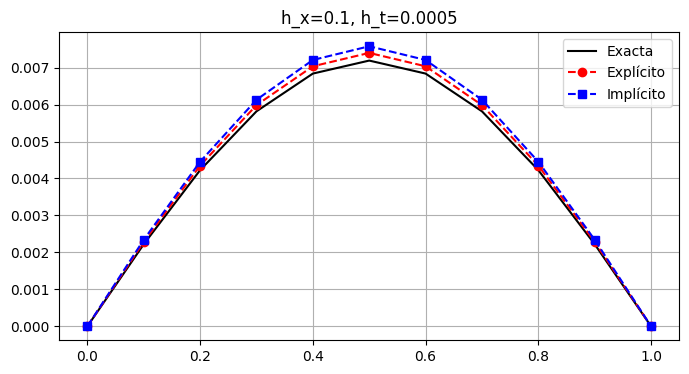


 CASO: hx=0.1, ht=0.01

 i   x_i     exacta     explícito      implícito
--------------------------------------------------------
 0  0.00   0.000000   0.000000   0.000000
 1  0.10   0.002222   -158422.838864   0.002898
 2  0.20   0.004227   305172.399216   0.005512
 3  0.30   0.005818   -428253.938791   0.007587
 4  0.40   0.006840   515620.221554   0.008919
 5  0.50   0.007192   -556349.995657   0.009378
 6  0.60   0.006840   542621.642363   0.008919
 7  0.70   0.005818   -471943.155403   0.007587
 8  0.80   0.004227   348861.615829   0.005512
 9  0.90   0.002222   -185424.259673   0.002898
10  1.00   0.000000   0.000000   0.000000

Errores:
Error explícito   = 556350.0028491648
Error implícito   = 0.0021862954850414094


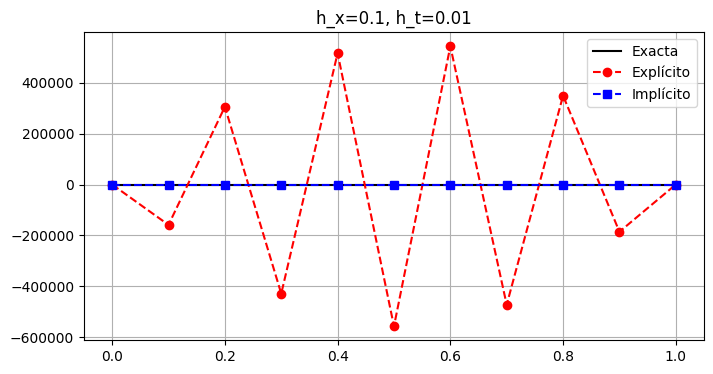

In [ ]:
# Proyecto 4.6.1 EL MÈTODO DE LA DEIFERENCIA REGRESIVA PARA LA ECUACION DE DIFUSION
# Nombre: FIERRO GUTIÈRREZ DANIELA

import numpy as np
import matplotlib.pyplot as plt
from math import sin, pi, exp

#    SOLUCIÓN ANALÍTICA
def analytical_u(x, t):
    return np.exp(-pi**2 * t) * np.sin(pi * x)

#    GAUSS–SEIDEL PARA SISTEMAS TRIDIAGONALES
def gauss_seidel_tridiag(a, b, c, d, tol=1e-10, max_iter=5000):
    """
    Resuelve el sistema Ax = d,
    donde A es tridiagonal:
      a = subdiagonal (n-1)
      b = diagonal     (n)
      c = superdiagonal (n-1)
    usando Gauss–Seidel iterativo.
    """
    n = len(b)
    x = np.zeros(n)

    for k in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            sum1 = a[i-1] * x[i-1] if i > 0 else 0
            sum2 = c[i]   * x_old[i+1] if i < n-1 else 0
            x[i] = (d[i] - sum1 - sum2) / b[i]

        # verificamos convergencia
        err = np.linalg.norm(x - x_old) / np.linalg.norm(x)
        if err < tol:
            return x
    print("Gauss–Seidel NO convergió")
    return x

#    MÉTODO EXPLÍCITO (PROGRESIVO)
def explicit_method(hx, ht, t_final):
    N = int(1/hx)
    x = np.linspace(0, 1, N+1)
    lambda_ = ht / hx**2
    nt = int(t_final/ht)

    w = analytical_u(x,0)   # inicial
    interior = np.arange(1,N)

    for _ in range(nt):
        w_old = w.copy()
        for i in interior:
            w[i] = w_old[i] + lambda_*(w_old[i+1] - 2*w_old[i] + w_old[i-1])
    return x, w


#   MÉTODO IMPLÍCITO (REGRESIVO) con GAUSS–SEIDEL
def implicit_method(hx, ht, t_final):
    N = int(1/hx)
    x = np.linspace(0, 1, N+1)
    lambda_ = ht / hx**2
    nt = int(t_final/ht)

    w = analytical_u(x,0)    # IC
    interior = np.arange(1,N)
    M = N-1   # número de incógnitas

    # Matriz tridiagonal A
    a = np.full(M-1, -lambda_)
    b = np.full(M,   1 + 2*lambda_)
    c = np.full(M-1, -lambda_)

    for _ in range(nt):
        d = w[1:N]       # RHS
        sol = gauss_seidel_tridiag(a,b,c,d)
        w[1:N] = sol

    return x, w

#    RESULTADOS
def run_case(hx, ht):
    print(f"\n===============================")
    print(f" CASO: hx={hx}, ht={ht}")
    print("===============================\n")

    t_final = 0.5
    x, w_exp = explicit_method(hx, ht, t_final)
    _, w_imp = implicit_method(hx, ht, t_final)
    u_exact = analytical_u(x,t_final)

    print(" i   x_i     exacta     explícito      implícito")
    print("--------------------------------------------------------")
    for i in range(len(x)):
        we = w_exp[i]
        wi = w_imp[i]
        ue = u_exact[i]
        print(f"{i:2d}  {x[i]:.2f}   {ue:.6f}   {we:.6f}   {wi:.6f}")

    print("\nErrores:")
    print("Error explícito   =", np.max(np.abs(w_exp - u_exact)))
    print("Error implícito   =", np.max(np.abs(w_imp - u_exact)))

    # gráficas
    plt.figure(figsize=(8,4))
    plt.plot(x,u_exact,'k-',label="Exacta")
    plt.plot(x,w_exp,'ro--',label="Explícito")
    plt.plot(x,w_imp,'bs--',label="Implícito")
    plt.title(f"h_x={hx}, h_t={ht}")
    plt.grid()
    plt.legend()
    plt.show()


# CORRIDAS SOLICITADAS POR EL PROYECTO
run_case(0.1, 0.0005)
run_case(0.1, 0.01)